In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/drive/MyDrive/Capstone 2025/Panic_Attack_Extra_Feature_Version.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         1200 non-null   int64  
 1   Age                        1200 non-null   int64  
 2   Gender                     1200 non-null   int64  
 3   Panic_Attack_Frequency     1200 non-null   float64
 4   Duration_Minutes           1200 non-null   float64
 5   Trigger                    1200 non-null   int64  
 6   Heart_Rate                 1200 non-null   int64  
 7   Sweating                   1200 non-null   int64  
 8   Shortness_of_Breath        1200 non-null   int64  
 9   Dizziness                  1200 non-null   int64  
 10  Chest_Pain                 1200 non-null   int64  
 11  Trembling                  1200 non-null   int64  
 12  Medical_History            1200 non-null   int64  
 13  Medication                 1200 non-null   int64

(None,
    ID  Age  Gender  Panic_Attack_Frequency  Duration_Minutes  Trigger  \
 0   1   56       0                     9.0               5.0        0   
 1   2   46       1                     8.0               9.0        4   
 2   3   32       0                     6.0              31.0        1   
 3   4   60       1                     5.0              20.0        0   
 4   5   25       2                     6.0              10.0        0   
 
    Heart_Rate  Sweating  Shortness_of_Breath  Dizziness  ...  \
 0         134         1                    0          1  ...   
 1         139         1                    1          0  ...   
 2         141         0                    1          1  ...   
 3         109         1                    1          0  ...   
 4         101         1                    0          1  ...   
 
    Heart_Rate_Category  Panic_Attack_Severity  Symptom_Count  Caffeine_Impact  \
 0                    0                   45.0              3            

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

# Summary statistics to identify outliers
summary_stats = df.describe()

# Checking unique values in categorical columns to validate encoding correctness
categorical_columns = ['Gender', 'Trigger', 'Medical_History', 'Medication',
                       'Smoking', 'Therapy', 'Heart_Rate_Category', 'Age_Group',
                       'Gender_Binary', 'History_of_Mental_Illness', 'High_Risk_Individual']
unique_values = {col: df[col].unique() for col in categorical_columns}

duplicate_rows, summary_stats, unique_values


(np.int64(0),
                 ID          Age       Gender  Panic_Attack_Frequency  \
 count  1200.000000  1200.000000  1200.000000             1200.000000   
 mean    600.500000    41.134167     0.637500                4.412500   
 std     346.554469    13.543412     0.649188                2.847648   
 min       1.000000    18.000000     0.000000                0.000000   
 25%     300.750000    29.000000     0.000000                2.000000   
 50%     600.500000    42.000000     1.000000                4.000000   
 75%     900.250000    53.000000     1.000000                7.000000   
 max    1200.000000    64.000000     2.000000                9.000000   
 
        Duration_Minutes      Trigger   Heart_Rate     Sweating  \
 count        1200.00000  1200.000000  1200.000000  1200.000000   
 mean           24.39250     2.483333   120.302500     0.696667   
 std            11.39993     1.716249    23.369912     0.459890   
 min             5.00000     0.000000    80.000000     0.00

Data cleaning

In [ ]:

# Drop constant-value columns
columns_to_drop = ["Caffeine_Impact", "Exercise_vs_Stress", "History_of_Mental_Illness", "High_Risk_Individual"]
df_cleaned = df.drop(columns=columns_to_drop)

# Mapping Gender values (if encoded incorrectly)
gender_mapping = {0: "Male", 1: "Female", 2: "Other"}
if "Gender" in df_cleaned.columns:
    df_cleaned["Gender"] = df_cleaned["Gender"].map(gender_mapping)

# Handle missing values (Fill with mode for categorical and median for numerical)
for col in df_cleaned.select_dtypes(include=["object"]).columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

for col in df_cleaned.select_dtypes(include=["number"]).columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Check cleaned dataset
df_cleaned.info(), df_cleaned.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      1200 non-null   int64  
 1   Age                     1200 non-null   int64  
 2   Gender                  1200 non-null   object 
 3   Panic_Attack_Frequency  1200 non-null   float64
 4   Duration_Minutes        1200 non-null   float64
 5   Trigger                 1200 non-null   int64  
 6   Heart_Rate              1200 non-null   int64  
 7   Sweating                1200 non-null   int64  
 8   Shortness_of_Breath     1200 non-null   int64  
 9   Dizziness               1200 non-null   int64  
 10  Chest_Pain              1200 non-null   int64  
 11  Trembling               1200 non-null   int64  
 12  Medical_History         1200 non-null   int64  
 13  Medication              1200 non-null   int64  
 14  Caffeine_Intake         1200 non-null   

(None,
    ID  Age  Gender  Panic_Attack_Frequency  Duration_Minutes  Trigger  \
 0   1   56    Male                     9.0               5.0        0   
 1   2   46  Female                     8.0               9.0        4   
 2   3   32    Male                     6.0              31.0        1   
 3   4   60  Female                     5.0              20.0        0   
 4   5   25   Other                     6.0              10.0        0   
 
    Heart_Rate  Sweating  Shortness_of_Breath  Dizziness  ...  Sleep_Hours  \
 0         134         1                    0          1  ...          6.4   
 1         139         1                    1          0  ...          5.0   
 2         141         0                    1          1  ...          8.3   
 3         109         1                    1          0  ...          5.3   
 4         101         1                    0          1  ...          7.2   
 
    Alcohol_Consumption  Smoking  Therapy  Heart_Rate_Category  \
 0         

lable encoding


In [ ]:
from sklearn.preprocessing import LabelEncoder

# List of columns to apply Label Encoding
label_cols = ["Gender", "Heart_Rate_Category", "Age_Group", "Trigger", "Medical_History", "Therapy"]

# Apply Label Encoding
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Store encoder for future inverse transformations

# Check the transformed data
df_cleaned.head()


,ID,Age,Gender,Panic_Attack_Frequency,Duration_Minutes,Trigger,Heart_Rate,Sweating,Shortness_of_Breath,Dizziness,...,Sleep_Hours,Alcohol_Consumption,Smoking,Therapy,Heart_Rate_Category,Panic_Attack_Severity,Symptom_Count,Medication_Dependency,Age_Group,Gender_Binary
0,1,56,1,9.0,5.0,0,134,1,0,1,...,6.4,5.0,1,1,0,45.0,3,0,1,2.0
1,2,46,0,8.0,9.0,4,139,1,1,0,...,5.0,3.0,0,1,0,72.0,2,1,1,2.0
2,3,32,1,6.0,31.0,1,141,0,1,1,...,8.3,8.0,0,1,0,186.0,2,0,0,2.0
3,4,60,0,5.0,20.0,0,109,1,1,0,...,5.3,8.0,0,0,2,100.0,3,0,1,2.0
4,5,25,2,6.0,10.0,0,101,1,0,1,...,7.2,2.0,0,0,2,60.0,4,0,2,2.0


One hot encoding

In [ ]:
# List of categorical columns for One-Hot Encoding
one_hot_cols = ["Medication", "Smoking"]

# Apply One-Hot Encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=one_hot_cols, drop_first=True)

# Display dataset after encoding
df_cleaned.head()

,ID,Age,Gender,Panic_Attack_Frequency,Duration_Minutes,Trigger,Heart_Rate,Sweating,Shortness_of_Breath,Dizziness,...,Alcohol_Consumption,Therapy,Heart_Rate_Category,Panic_Attack_Severity,Symptom_Count,Medication_Dependency,Age_Group,Gender_Binary,Medication_1,Smoking_1
0,1,56,1,9.0,5.0,0,134,1,0,1,...,5.0,1,0,45.0,3,0,1,2.0,False,True
1,2,46,0,8.0,9.0,4,139,1,1,0,...,3.0,1,0,72.0,2,1,1,2.0,True,False
2,3,32,1,6.0,31.0,1,141,0,1,1,...,8.0,1,0,186.0,2,0,0,2.0,False,False
3,4,60,0,5.0,20.0,0,109,1,1,0,...,8.0,0,2,100.0,3,0,1,2.0,False,False
4,5,25,2,6.0,10.0,0,101,1,0,1,...,2.0,0,2,60.0,4,0,2,2.0,False,False


In [ ]:
# Save the cleaned dataset to a CSV file
df_cleaned.to_csv("Panic_Attack_Cleaned.csv", index=False)


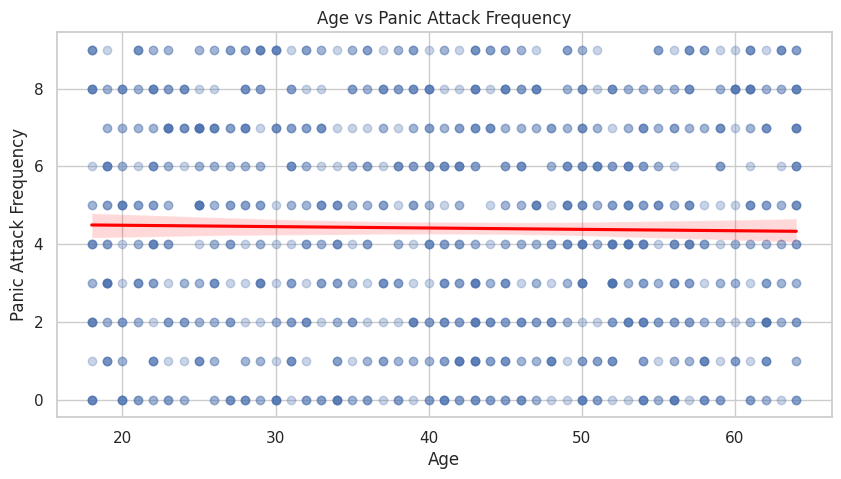

Age vs Panic Attack Frequency Correlation: -0.016790315969187477


<ipython-input-24-b90942b28b93>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Caffeine_Intake"], y=df["Panic_Attack_Frequency"], palette="coolwarm")


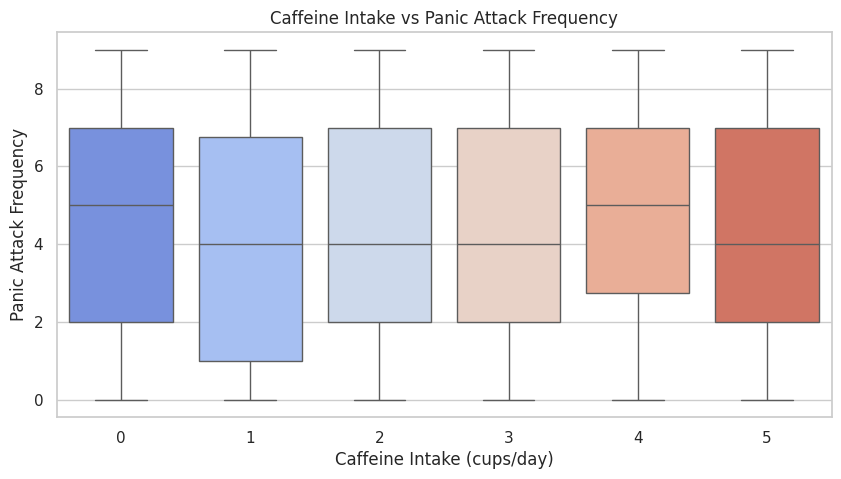

Caffeine Intake vs Panic Attack Frequency Correlation: 0.00036037753462005585


<ipython-input-24-b90942b28b93>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Exercise_Frequency"], y=df["Panic_Attack_Frequency"], palette="viridis")


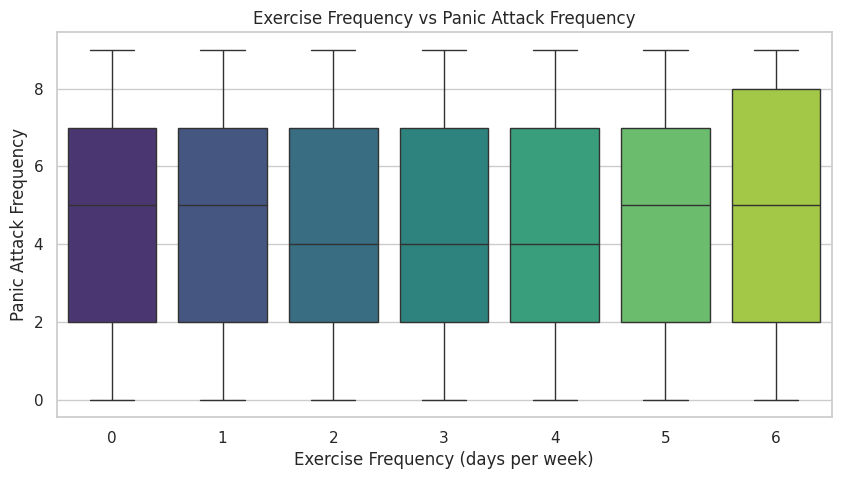

Exercise Frequency vs Panic Attack Frequency Correlation: 0.0011756435380511998


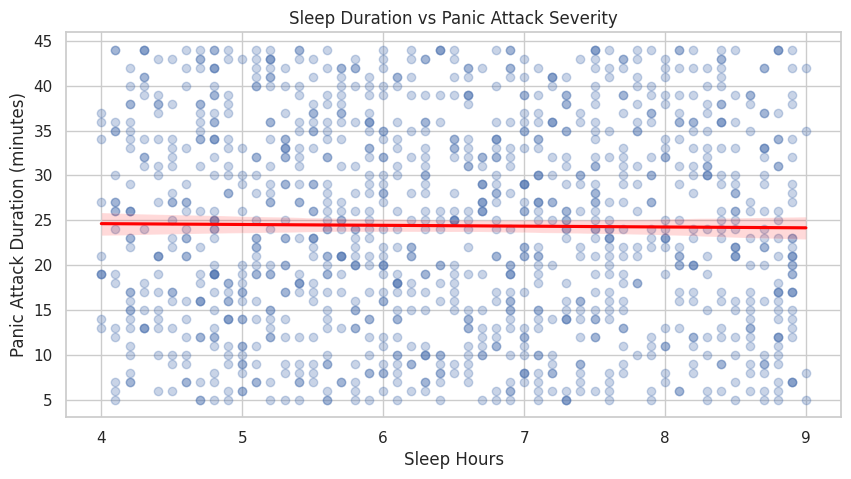

Sleep Duration vs Panic Attack Severity Correlation: -0.01147805720925263


<ipython-input-24-b90942b28b93>:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trigger_means.index, y=trigger_means.values, palette="magma")


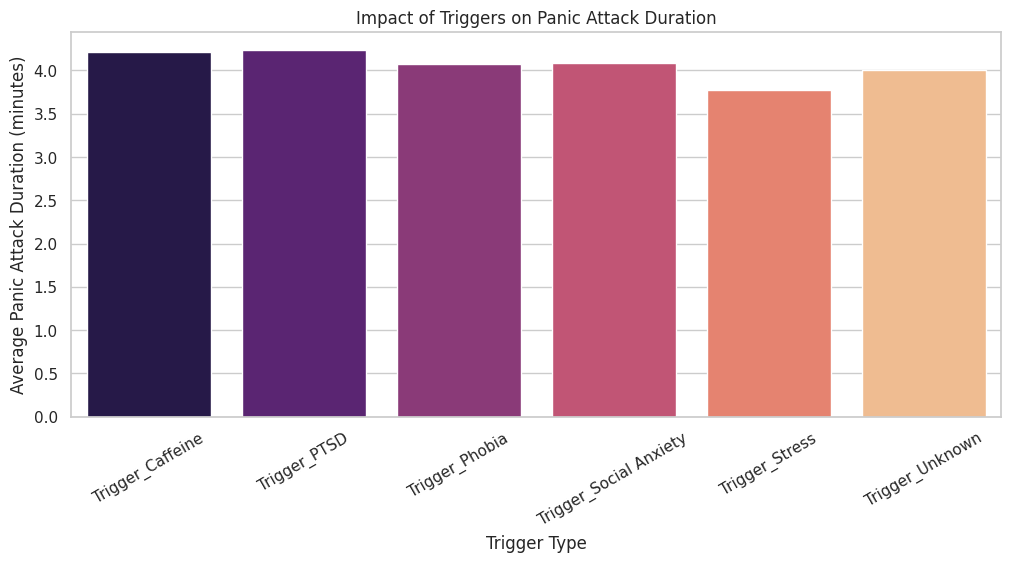

<ipython-input-24-b90942b28b93>:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[condition], y=df["Panic_Attack_Frequency"], palette="Set2")


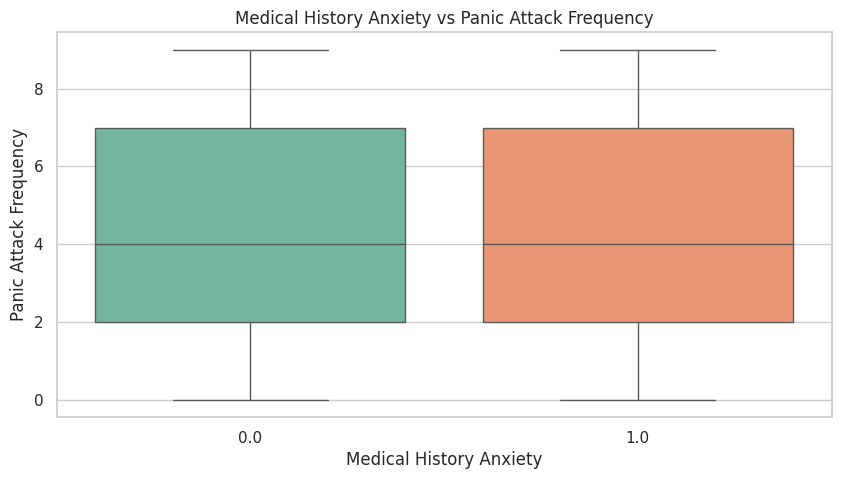

Medical History Anxiety vs Panic Attack Frequency Correlation: 0.03395870624767244


<ipython-input-24-b90942b28b93>:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[condition], y=df["Panic_Attack_Frequency"], palette="Set2")


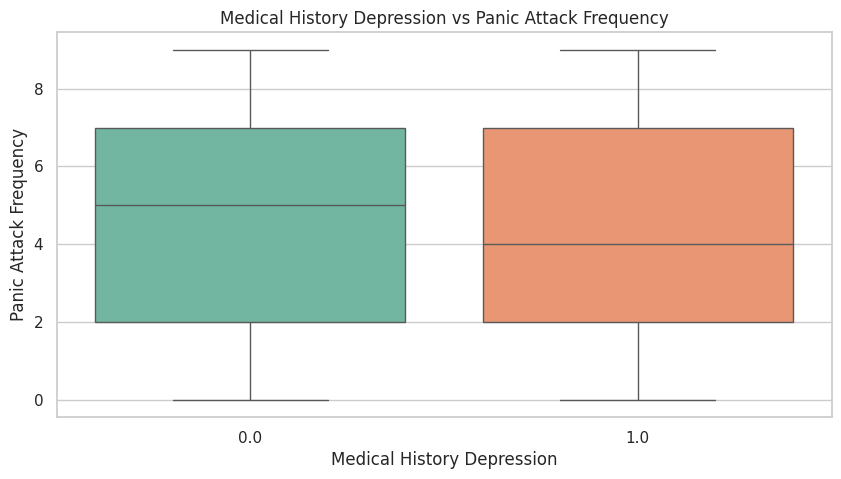

Medical History Depression vs Panic Attack Frequency Correlation: -0.05863805575565527


<ipython-input-24-b90942b28b93>:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[condition], y=df["Panic_Attack_Frequency"], palette="Set2")


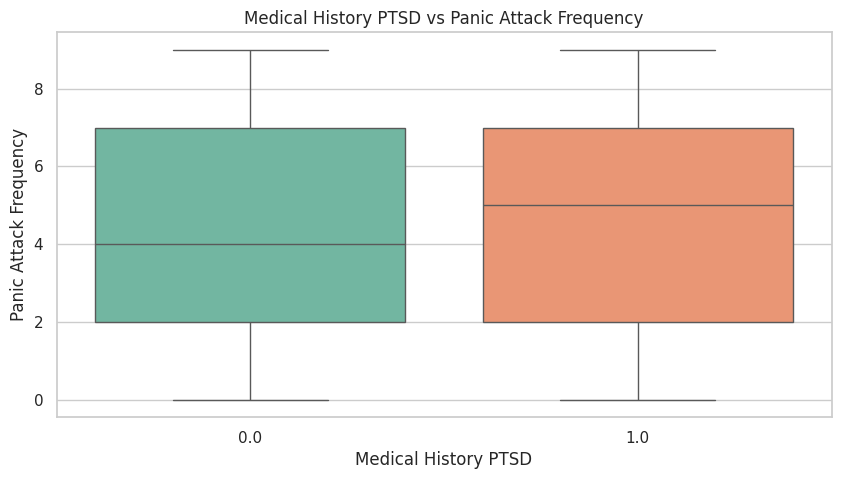

Medical History PTSD vs Panic Attack Frequency Correlation: 0.02223582423673061


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "/content/drive/MyDrive/Capstone 2025/Panic_Attack_OHE_Enocde_Version.csv"
df = pd.read_csv(file_path)

sns.set_style("whitegrid")

### 1. How does age affect panic attack frequency?
plt.figure(figsize=(10, 5))
sns.regplot(x=df["Age"], y=df["Panic_Attack_Frequency"], scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.xlabel("Age")
plt.ylabel("Panic Attack Frequency")
plt.title("Age vs Panic Attack Frequency")
plt.show()

print("Age vs Panic Attack Frequency Correlation:", df["Age"].corr(df["Panic_Attack_Frequency"]))

### 2. Does caffeine intake influence the number of panic attacks?
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Caffeine_Intake"], y=df["Panic_Attack_Frequency"], palette="coolwarm")
plt.xlabel("Caffeine Intake (cups/day)")
plt.ylabel("Panic Attack Frequency")
plt.title("Caffeine Intake vs Panic Attack Frequency")
plt.show()

print("Caffeine Intake vs Panic Attack Frequency Correlation:", df["Caffeine_Intake"].corr(df["Panic_Attack_Frequency"]))

### 3. What is the relationship between exercise and panic attack frequency?
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Exercise_Frequency"], y=df["Panic_Attack_Frequency"], palette="viridis")
plt.xlabel("Exercise Frequency (days per week)")
plt.ylabel("Panic Attack Frequency")
plt.title("Exercise Frequency vs Panic Attack Frequency")
plt.show()

print("Exercise Frequency vs Panic Attack Frequency Correlation:", df["Exercise_Frequency"].corr(df["Panic_Attack_Frequency"]))

### 4. Does sleep duration correlate with panic attack severity?
plt.figure(figsize=(10, 5))
sns.regplot(x=df["Sleep_Hours"], y=df["Duration_Minutes"], scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.xlabel("Sleep Hours")
plt.ylabel("Panic Attack Duration (minutes)")
plt.title("Sleep Duration vs Panic Attack Severity")
plt.show()

print("Sleep Duration vs Panic Attack Severity Correlation:", df["Sleep_Hours"].corr(df["Duration_Minutes"]))

### 5. How do different triggers impact attack duration?
triggers = ["Trigger_Caffeine", "Trigger_PTSD", "Trigger_Phobia", "Trigger_Social Anxiety", "Trigger_Stress", "Trigger_Unknown"]
trigger_means = df[triggers].mul(df["Duration_Minutes"], axis=0).mean()

plt.figure(figsize=(12, 5))
sns.barplot(x=trigger_means.index, y=trigger_means.values, palette="magma")
plt.xticks(rotation=30)
plt.xlabel("Trigger Type")
plt.ylabel("Average Panic Attack Duration (minutes)")
plt.title("Impact of Triggers on Panic Attack Duration")
plt.show()

### 6. Do people with medical histories experience more frequent or severe panic attacks?
medical_conditions = ["Medical_History_Anxiety", "Medical_History_Depression", "Medical_History_PTSD"]
for condition in medical_conditions:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[condition], y=df["Panic_Attack_Frequency"], palette="Set2")
    plt.xlabel(condition.replace("_", " "))
    plt.ylabel("Panic Attack Frequency")
    plt.title(f"{condition.replace('_', ' ')} vs Panic Attack Frequency")
    plt.show()

    print(f"{condition.replace('_', ' ')} vs Panic Attack Frequency Correlation:", df[condition].corr(df["Panic_Attack_Frequency"]))


In [ ]:
correlations = df_cleaned[["Sleep_Hours", "Alcohol_Consumption", "Exercise_Frequency",
                           "Caffeine_Intake", "Heart_Rate", "Panic_Attack_Severity"]].corr()
print(correlations["Panic_Attack_Severity"].sort_values(ascending=False))


Panic_Attack_Severity    1.000000
Heart_Rate               0.029888
Sleep_Hours             -0.001561
Exercise_Frequency      -0.018999
Alcohol_Consumption     -0.020638
Caffeine_Intake         -0.024453
Name: Panic_Attack_Severity, dtype: float64


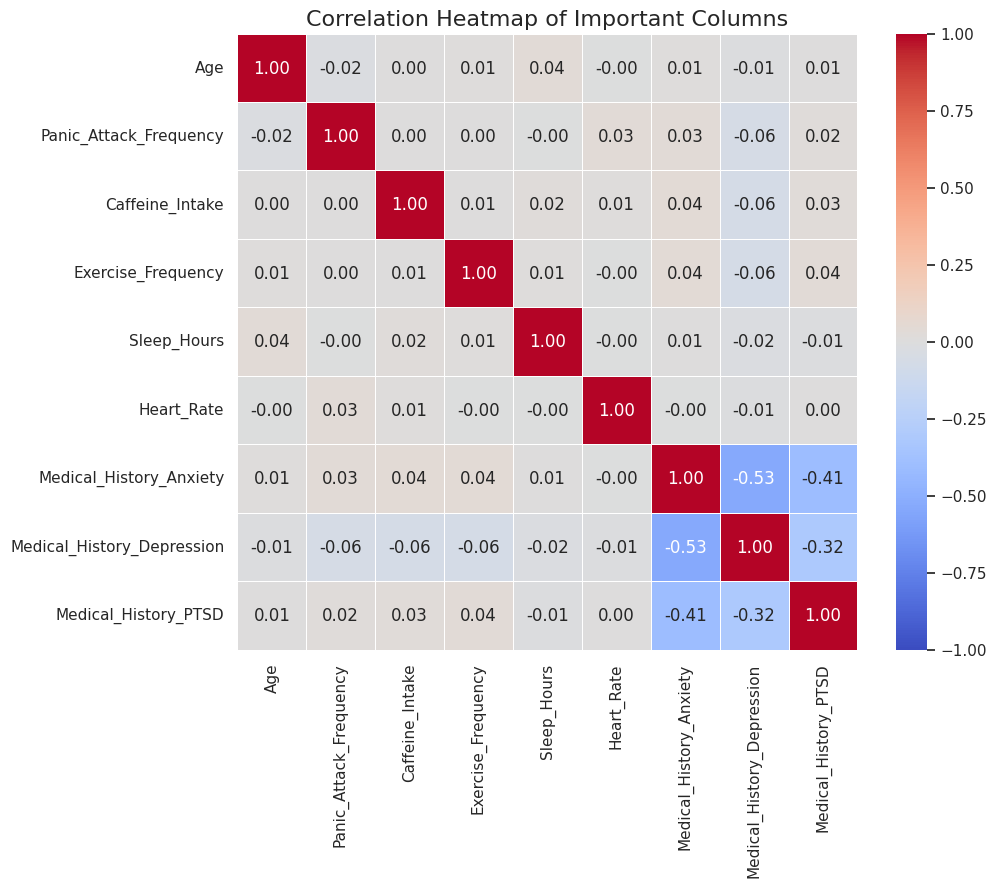

In [ ]:
# List of important numerical columns to focus on
important_columns = [
    'Age',
    'Panic_Attack_Frequency',
    'Caffeine_Intake',
    'Exercise_Frequency',
    'Sleep_Hours',
    'Heart_Rate',
    'Medical_History_Anxiety',
    'Medical_History_Depression',
    'Medical_History_PTSD'
]

# Select only the important columns from the dataframe
df_important = df[important_columns]

# Calculate the correlation matrix for the important columns
corr_matrix = df_important.corr()

# Set up the figure size
plt.figure(figsize=(10, 8))

# Generate the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

# Title and display the plot
plt.title("Correlation Heatmap of Important Columns", fontsize=16)
plt.show()
